In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import time
from PolynomialApproximators import (RemezPolynomial, MangPolynomial, SunderhaufPolynomial,Chebyshev, SpectralPolynomial, BASE_POLYS,spectral_correction)
from QSVTSolvers  import (StandardQSVT, PureSpectralQSVT, SpectrallyBootstrappedQSVT)
from PoissonFunctions import build_1d_poisson, eigs_1d_poisson,build_2d_poisson, eigs_2d_poisson

## Functions to run experiments and plot

In [2]:

# ══════════════════════════════════════════════════════════════════════════════
# Colour / style palette  (used consistently across all figures)
# ══════════════════════════════════════════════════════════════════════════════
_C = {
    "Remez":      "#1f77b4",   # steel blue
    "Mang":       "#d62728",   # brick red
    "Sunderhauf": "#2ca02c",   # forest green
    "Eigenvalue": "#9467bd",   # purple
    "spectral":     "#ff7f0e",   # orange  (Mang + correction)
    "Grey":       "#555555",
}
_LS = {"Remez": "-", "Mang": "--", "Sunderhauf": "-.", "Eigenvalue": ":"}
_MK = {"Remez": "o", "Mang": "s", "Sunderhauf": "^", "Eigenvalue": "D"}


def _styled_axes(ax):
    """Apply consistent grey-background grid style to an axes."""
    ax.set_facecolor("#f7f7f7")
    ax.grid(True, which="major", color="white", lw=1.2, zorder=0)
    ax.grid(True, which="minor", color="white", lw=0.5, alpha=0.6, zorder=0)
    ax.tick_params(labelsize=9)



def plot_base_polynomals(kappa: float = 10.0,
                       epsilon: float = 0.2,
                       n_points: int = 2000,
                       save_path: str = None) -> plt.Figure:
    """
    Plot p(x) vs 1/x on [a, 1] for Remez, Mang, and Sunderhauf.

    Parameters
    ----------
    kappa     : condition number (kappa = 1/a)
    epsilon   : target approximation accuracy
    n_points  : number of evaluation points on [a, 1]
    save_path : if given, save figure to this path (e.g. 'fig.pdf')

    Returns
    -------
    matplotlib Figure
    """
    a = 1.0 / kappa

    # ── find minimum degree for each method ──────────────────────────────────
    d_remez = RemezPolynomial.mindegree(epsilon, a)
    d_mang  = MangPolynomial.mindegree(epsilon, a)
    d_sund  = SunderhaufPolynomial.mindegree(epsilon, a)

    # ── build polynomials ─────────────────────────────────────────────────────
    p_remez = RemezPolynomial.poly(d_remez, a)
    p_mang  = MangPolynomial.poly(d_mang,  a)
    p_sund  = SunderhaufPolynomial.poly(d_sund, a)

    # ── evaluate on [a, 1] ───────────────────────────────────────────────────
    x = np.linspace(a, 1.0, n_points)

    y_exact = 1.0 / x
    y_remez = p_remez(x)
    y_mang  = p_mang(x)
    y_sund  = p_sund(x)

    # ── plot ──────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(5, 3.5))

    ax.plot(x, y_exact, color='k',  lw=2.0, linestyle=':',
            label=r'$1/x$ (exact)')
    ax.plot(x, y_remez, color='C0', lw=1.5,
            label=rf'Remez ($d={d_remez}$)')
    ax.plot(x, y_mang,  color='C1', lw=1.5, linestyle='--',
            label=rf'Mang ($d={d_mang}$)')
    ax.plot(x, y_sund,  color='C2', lw=1.5, linestyle='-.',
            label=rf'Sund$\ddot{{e}}$rhauf ($d={d_sund}$)')

    ax.set_xlabel(r'$x$', fontsize=14)
    ax.set_ylabel(r'$p(x)$', fontsize=14)
    ax.tick_params(labelsize=11)
    ax.legend(fontsize=10, loc='upper right')
    ax.set_xlim(0, 1.1)
    ax.set_ylim(0, kappa * 1.1)
    ax.grid(True, alpha=0.3)

    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved to {save_path}")

    return fig


def plot_base_polynomial_errors(kappa: float = 10.0,
                      epsilon: float = 0.2,
                      n_points: int = 2000,
                      save_path: str = None) -> plt.Figure:
    """
    Plot |x p(x) - 1| on [a, 1] for Remez, Mang, and Sunderhauf.

    Parameters
    ----------
    kappa     : condition number (kappa = 1/a)
    epsilon   : target approximation accuracy
    n_points  : number of evaluation points on [a, 1]
    save_path : if given, save figure to this path (e.g. 'fig.pdf')

    Returns
    -------
    matplotlib Figure
    """
    a = 1.0 / kappa

    # ── find minimum degree for each method ──────────────────────────────────
    d_remez = RemezPolynomial.mindegree(epsilon, a)
    d_mang  = MangPolynomial.mindegree(epsilon, a)
    d_sund  = SunderhaufPolynomial.mindegree(epsilon, a)

    # ── build polynomials ─────────────────────────────────────────────────────
    p_remez = RemezPolynomial.poly(d_remez, a)
    p_mang  = MangPolynomial.poly(d_mang,  a)
    p_sund  = SunderhaufPolynomial.poly(d_sund, a)

    # ── evaluate error on [a, 1] ──────────────────────────────────────────────
    x = np.linspace(a, 1.0, n_points)

    e_remez = np.abs(x * p_remez(x) - 1.0)
    e_mang  = np.abs(x * p_mang(x)  - 1.0)
    e_sund  = np.abs(x * p_sund(x)  - 1.0)

    # ── plot ──────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(5, 3.5))

    ax.semilogy(x, e_remez, color='C0', lw=1.5,
                label=rf'Remez ($d={d_remez}$)')
    ax.semilogy(x, e_mang,  color='C1', lw=1.5, linestyle='--',
                label=rf'Mang ($d={d_mang}$)')
    ax.semilogy(x, e_sund,  color='C2', lw=1.5, linestyle='-.',
                label=rf'Sund$\ddot{{e}}$rhauf ($d={d_sund}$)')

    ax.axhline(epsilon, color='k', lw=1.0, linestyle=':',
               label=rf'$\varepsilon = {epsilon}$')

    ax.set_xlabel(r'$x$', fontsize=14)
    ax.set_ylabel(r'$|x\,p(x) - 1|$', fontsize=14)
    ax.tick_params(labelsize=11)
    ax.legend(fontsize=10, loc='lower right')
    ax.set_xlim(0, 1.1)
    ax.yaxis.set_major_locator(ticker.LogLocator(base=10, numticks=8))
    ax.grid(True, which='both', alpha=0.3)

    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved to {save_path}")

    return fig

def plot_pure_spectral_polynomial(lams: np.ndarray, 
                       n_points: int = 2000,
                       save_path: str = None) -> plt.Figure:
    """
    

    Returns
    -------
    matplotlib Figure
    """
    
    lams /= np.max(lams)*1.01   # normalize to [0, 1] with a small margin

    sp = SpectralPolynomial(lams)
    # ── evaluate on [a, 1] ───────────────────────────────────────────────────
    a = np.min(lams)
    x = np.linspace(a, 1.0, n_points)

    y_exact = 1.0 / x
    y_spectral = sp.poly()(x)

    tau_spectral = np.max(np.abs(y_spectral))
    print(f"Max tau for pure spectral polynomial: {tau_spectral:.4f}")
    # ── plot ──────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(5, 3.5))

    ax.plot(x, y_exact, color='k',  lw=2.0, linestyle=':',
            label=r'$1/x$ (exact)')
    ax.plot(x, y_spectral, color='C3', lw=1.5,
            label=rf'Spectral ($K={len(lams)}$)')

    ax.set_xlabel(r'$x$', fontsize=14)
    ax.set_ylabel(r'$p(x)$', fontsize=14)
    ax.tick_params(labelsize=11)
    ax.legend(fontsize=10, loc='upper right')
    ax.set_xlim(0, 1.1)
    ax.grid(True, alpha=0.3)

    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved to {save_path}")

    return 

def plot_bootstrapped_spectral_compare_error(kappa: float,
                        epsilon: float,
                        eigenvalues: np.ndarray,
                        base: str = 'mang',
                        n_points: int = 4000,
                        save_path: str = None) -> plt.Figure:
    """
    Plot |x p(x) - 1| for the base polynomial and the spectral corrected
    polynomial. Eigenvalue locations are marked as vertical lines.

    Parameters
    ----------
    kappa       : condition number; determines a = 1/kappa for the base poly
    epsilon     : target accuracy for the base polynomial
    eigenvalues : array of K known eigenvalues in (0, 1]; must satisfy
                  min(eigenvalues) >= 1/kappa = a
    base        : 'remez', 'mang', or 'sunderhauf'
    n_points    : evaluation points on [a, 1]
    save_path   : optional output path (e.g. 'fig.pdf')

    Returns
    -------
    matplotlib Figure
    """
    a   = 1.0 / kappa
    lam = np.sort(np.asarray(eigenvalues))
    K   = len(lam)

    if lam[0] < a:
        raise ValueError(
            f"Smallest eigenvalue {lam[0]:.4g} < a = {a:.4g}. "
            f"Use kappa = 1/min(eigenvalues) = {1/lam[0]:.3f}."
        )

    # ── build base polynomial ─────────────────────────────────────────────────
    cls = BASE_POLYS[base.lower()]
    d0  = cls.mindegree(epsilon, a)
    p0  = cls.poly(d0, a)

    # ── spectral correction ─────────────────────────────────────────────────────
    c_corr       = spectral_correction(p0, lam)
    coef_H       = p0.coef.copy()
    coef_H[1::2] += c_corr
    p_H          = Chebyshev(coef_H)

    # ── evaluate on [a, 1], including eigenvalues exactly ────────────────────
    x      = np.union1d(np.linspace(a, 1.0, n_points), lam)
    y_base = p0(x)
    y_H    = p_H(x)
    e_base = np.abs(x * y_base - 1.0)
    e_hybr = np.abs(x * y_H - 1.0)

    tau_base = np.max(np.abs(y_base))
    tau_hybr = np.max(np.abs(y_H))
    print(f"Max tau on [a, 1]: base={tau_base:.4f}, spectral={tau_hybr:.4f}")
    max_error_base = np.max(e_base)
    max_error_hybr = np.max(e_hybr)
    print(f"Max error on [a, 1]: base={max_error_base:.4f}, spectral={max_error_hybr:.4f}")

    # errors at eigenvalues
    e_base_eig = np.abs(lam * p0(lam) - 1.0)
    e_hybr_eig = np.abs(lam * p_H(lam) - 1.0)

    # ── plot ──────────────────────────────────────────────────────────────────
    base_label = {'remez': 'Remez', 'mang': 'Mang',
                  'sunderhauf': r'Sund$\ddot{e}$rhauf'}[base.lower()]

    fig, ax = plt.subplots(figsize=(5, 3.5))          # narrow for one column

    ax.semilogy(x, e_base, color='C0', lw=1.5,
            label=rf'{base_label} ($d={d0}$, $\varepsilon={max_error_base:.3f}$)')
    ax.semilogy(x, e_hybr, color='C1', lw=1.5, linestyle='--',
            label=rf'Spectral-{base_label} ($d={d0}$, $\varepsilon={max_error_hybr:.3f}$)')

    ax.semilogy(lam, e_base_eig, 'o', color='C0', ms=6, zorder=5,
                label=r'$|\lambda_k p_0(\lambda_k)-1|$')
    ax.semilogy(lam, e_hybr_eig, 's', color='C1', ms=6, zorder=5,
                label=r'$|\lambda_k p_S(\lambda_k)-1|$')

    ax.axhline(epsilon, color='k', lw=1.0, linestyle=':',
               label=rf'$\varepsilon = {epsilon}$')

    for lk in lam:
        ax.axvline(lk, color='gray', lw=0.5, alpha=0.4)

    ax.set_xlabel(r'$x$', fontsize=14)
    ax.set_ylabel(r'$|x\,p(x) - 1|$', fontsize=14)
    ax.tick_params(labelsize=11)

    # no title — caption carries this information
    ax.legend(fontsize=10, loc='lower center')
    ax.set_xlim(0, 1.1)                               # fixed: was (0, 1.1)
    ax.yaxis.set_major_locator(ticker.LogLocator(base=10, numticks=10))
    ax.grid(True, which='both', alpha=0.3)

    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved to {save_path}")

    return fig


def print_accuracy_table_1D(m: int = 2, KFactor: float = 0.5,  base: str = 'Sunderhauf'):
    """
        degree_accuracy_experiment.py
        ==============================
        Reproduces Table: Degree--accuracy trade-off for Mang vs spectral-Mang.

        Reports E_eig separately at:
        - corrected eigenvalues (K smallest)
        - all N eigenvalues
        """
    N  = 2**m
    K = int(KFactor * N)
    h  = 1.0 / (N + 1)
    k  = np.arange(1, N + 1)

    lam_all = (4.0/h**2) * np.sin(k * np.pi / (2*(N+1)))**2
    lam_all /= lam_all[-1]

    kappa = 1.0 / lam_all[0]
    a     = 1.0 / kappa
    lam_K = lam_all[:K]

    print(f"N={N}, kappa={kappa:.2f}, K={K}\n")


    def eig_residuals(p, eigenvalues):
        vals = np.abs(eigenvalues * p(eigenvalues) - 1.0)
        return np.maximum(vals, 1e-16)  # avoid exact zero


    # ── experiment ────────────────────────────────────────────────────────────────
    epsilons = [0.2, 0.1, 0.01]

    fmt = f"{'Method':<22} {'eps':>10} {'d':>6}  {'E_eig (K corrected)':>20}  {'E_eig (all N)':>14}"
    print(fmt)
    print('-' * len(fmt))
    cls = BASE_POLYS[base.lower()]
    for eps in epsilons:
        d0 = cls.mindegree(eps, a)
        p0 = cls.poly(d0, a)

        # spectral
        coef_H        = p0.coef.copy()
        coef_H[1::2] += spectral_correction(p0, lam_K)
        p_H           = Chebyshev(coef_H)

        # residuals at corrected vs all eigenvalues
        r0_K   = np.max(eig_residuals(p0, lam_K))
        rH_K   = np.max(eig_residuals(p_H, lam_K))
        r0_all = np.max(eig_residuals(p0, lam_all))
        rH_all = np.max(eig_residuals(p_H, lam_all))

        eps_str = f"{eps:.0e}" if eps < 0.01 else f"{eps:.3f}"
        print(f"{base:<22} {eps_str:>10} {d0:>6d}  {r0_K:>20.2e}  {r0_all:>14.2e}")
        spectral_label = f"Spectral-{base} (K={K})"
        print(f"{spectral_label:<22} {eps_str:>7} {d0:>6d}  {rH_K:>20.2e}  {rH_all:>14.2e}")          
        print()


# ── single trial ──────────────────────────────────────────────────────────────

def run_single_trial(A, b, kappa, lam_K_exact, x_cl, C_true,
                     eta, eps, rng, base='Mang'):
    """
    Run one QSVT trial with eigenvalues perturbed at level eta.

    Returns
    -------
    fidelity, compliance_err, success_prob
    """
    # perturb eigenvalues
    delta      = rng.uniform(-eta, eta, size=len(lam_K_exact))
    lam_K_pert = lam_K_exact * (1.0 + delta)

    # clip to valid range [a, 1]
    a          = 1.0 / kappa
    lam_K_pert = np.clip(lam_K_pert, a + 1e-10, 1.0 - 1e-10)

    try:
        solver = SpectrallyBootstrappedQSVT(A, b, lam_K=lam_K_pert, kappa=kappa,
                               target_error=eps, polyMethod=base)
        x_qsvt, succ_prob, norm_real = solver.solve(stateVector=True)

        C_qsvt         = float(b @ x_qsvt) * solver.tau * norm_real
        compliance_err = abs(C_qsvt - C_true) / abs(C_true)
        fidelity       = float(np.abs(np.vdot(x_qsvt, x_cl))**2)
        return fidelity, compliance_err, succ_prob

    except Exception as e:
        print(f"    Trial failed: {e}")
        return None, None, None
def _collect(x_qsvt, x_cl, succ_prob, norm_real, solver, b, C_true, elapsed):
    C_qsvt        = float(b @ x_qsvt) * solver.tau * norm_real
    compliance_err = abs(C_qsvt - C_true) / abs(C_true)
    fidelity       = float(np.abs(np.vdot(x_qsvt, x_cl))**2)
    max_err        = np.max(np.abs(x_qsvt - x_cl)) / np.max(np.abs(x_cl))
    return dict(degree=solver.degree, fidelity=fidelity,
                success_prob=succ_prob, tau=solver.tau,
                compliance_err=compliance_err, max_error=max_err,
                C_qsvt=C_qsvt, C_true=C_true, elapsed=elapsed,
                x_qsvt=x_qsvt)


def _print_experiment_summary(results, kappa, K, eps_loose, eps_tight, base='Sunderhauf'):
    print(f"\n{'='*85}")
    print(f"{'Method':<35} {'d':>5} {'Fidelity':>10} "
          f"{'Rel J err':>10} {'Succ.prob':>10} {'tau':>7}  {'Time':>7}")
    print(f"{'-'*85}")
    for label, r in results.items():
        print(f"{label:<35} {r['degree']:>5d} {r['fidelity']:>10.6f} "
              f"{r['compliance_err']:>10.2e} {r['success_prob']:>10.4f} "
              f"{r['tau']:>7.4f}  {r['elapsed']:>6.1f}s")
    print(f"{'='*85}")

    # highlight the key message
    methods = list(results.keys())
    d_loose  = results[methods[0]]['degree']
    d_tight  = results[methods[1]]['degree']
    d_spectral = results[methods[2]]['degree']
    F_loose  = results[methods[0]]['fidelity']
    F_tight  = results[methods[1]]['fidelity']
    F_spectral = results[methods[2]]['fidelity']

    print(f"\nKey result:")
    print(f"  Spectral-{base} at eps={eps_loose} (d={d_spectral}) achieves "
          f"fidelity {F_spectral:.6f}")
    print(f"  vs {base} at eps={eps_tight}   (d={d_tight})  fidelity {F_tight:.6f}")
    print(f"  vs {base} at eps={eps_loose}   (d={d_loose})  fidelity {F_loose:.6f}")
    print(f"  Circuit depth reduction: {d_tight}/{d_spectral} = {d_tight/d_spectral:.2f}x")

def run_1d_Poisson_spectral_experiment(m: int,
                          eps_loose: float = 0.1,
                          eps_tight: float = 0.001,
                          K_fraction: float = 0.5,
                          base: str = 'Sunderhauf',
                          function_type: str = "uniform"):
    """
    Run the three-way QSVT comparison for the 1D Poisson problem.

    Parameters
    ----------
    m             : log2(N) — number of qubits for the data register
    eps_loose     : loose tolerance for base and spectral methods
    eps_tight     : tight tolerance reference method
    K_fraction    : fraction of eigenvalues to correct (default 0.5 = N/2)
    base          : 'Mang', 'Sunderhauf', or 'Remez'
    function_type : 'uniform', 'sine', 'delta', or 'random'
    """
    N = 2**m
    K = max(1, int(round(K_fraction * N)))

    print(f"\n{'='*65}")
    print(f"1D Poisson QSVT spectral Experiment")
    print(f"m={m}, N={N}, K={K} (={K_fraction:.0%} of N)")
    print(f"eps_loose={eps_loose}, eps_tight={eps_tight}")
    print(f"base={base}, function_type={function_type}")
    print(f"{'='*65}")

    # ── build problem ─────────────────────────────────────────────────
    A, b   = build_1d_poisson(m, function_type=function_type)
    eigs = eigs_1d_poisson(m)
    eigMax = np.max(eigs)
    eigs /= (1.01*eigMax)
    A /= (1.01*eigMax)
    
    kappa  = 1.0 / float(eigs[0])     # 1/smallest
    lam_K  = eigs[:K]                  # K smallest, already ascending

    u_cl_unnorm = np.linalg.solve(A, b)
    C_true      = float(b @ u_cl_unnorm)
    x_cl        = u_cl_unnorm / np.linalg.norm(u_cl_unnorm)

    print(f"kappa={kappa:.3f}, lam_min={eigs[-1]:.6f}, lam_max={eigs[0]:.6f}")
    print(f"K smallest eigenvalues: {lam_K}")
    print(f"C_true = {C_true:.6f}")

    results = {}

    # ── (1) base, loose epsilon ───────────────────────────────────────
    label = f"{base} (eps={eps_loose})"
    print(f"\n--- {label} ---")
    t0 = time.time()
    solver = StandardQSVT(A, b, kappa=kappa, target_error=eps_loose,
                    polyMethod=base)
    x_qsvt, succ_prob, norm_real = solver.solve(stateVector=True)
    elapsed = time.time() - t0
    results[label] = _collect(x_qsvt, x_cl, succ_prob, norm_real,
                               solver, b, C_true, elapsed)

    # ── (2) base, tight epsilon ───────────────────────────────────────
    label = f"{base} (eps={eps_tight})"
    print(f"\n--- {label} ---")
    t0 = time.time()
    solver = StandardQSVT(A, b, kappa=kappa, target_error=eps_tight,
                    polyMethod=base)
    x_qsvt, succ_prob, norm_real = solver.solve(stateVector=True)
    elapsed = time.time() - t0
    results[label] = _collect(x_qsvt, x_cl, succ_prob, norm_real,
                               solver, b, C_true, elapsed)

    # ── (3) spectral-base, loose epsilon, K ───────────────────────────
    label = f"Spectral-{base} K={K} (eps={eps_loose})"
    print(f"\n--- {label} ---")
    t0 = time.time()
    solver = SpectrallyBootstrappedQSVT(A, b, lam_K=lam_K, kappa=kappa,
                           target_error=eps_loose, polyMethod=base)
    x_qsvt, succ_prob, norm_real = solver.solve(stateVector=True)
    elapsed = time.time() - t0
    results[label] = _collect(x_qsvt, x_cl, succ_prob, norm_real,
                               solver, b, C_true, elapsed)

    # ── summary ───────────────────────────────────────────────────────
    _print_experiment_summary(results, kappa, K, eps_loose, eps_tight, base=base)
    return results, x_cl

def run_1d_Poisson_perturbation_experiment(m: int = 4,
                                eps: float = 0.2,
                                K_fraction: float = 0.5,
                                eta_values: list = None,
                                n_trials: int = 10,
                                seed: int = 42,
                                base: str = 'Mang',
                                function_type: str = "uniform",
                                save_path: str = None):
    """
    Sweep over perturbation levels eta and report mean/std of
    fidelity and compliance error over n_trials random perturbations.

    Parameters
    ----------
    m             : log2(N)
    eps           : base polynomial tolerance
    K_fraction    : fraction of eigenvalues to correct
    eta_values    : list of perturbation levels (default logspace -4 to -1)
    n_trials      : number of random trials per eta
    seed          : random seed for reproducibility
    base          : 'Mang', 'Sunderhauf', or 'Remez'
    function_type : RHS type
    save_path     : if given, save figure to this path
    """
    if eta_values is None:
        eta_values = [0.0, 1e-4, 1e-3, 1e-2, 1e-1]

    N = 2**m
    K = max(1, int(round(K_fraction * N)))
    rng = np.random.default_rng(seed)

    print(f"\n{'='*65}")
    print(f"Perturbation robustness experiment")
    print(f"m={m}, N={N}, K={K}, eps={eps}, base={base}, n_trials={n_trials}")
    print(f"eta_values={eta_values}")
    print(f"{'='*65}")

    # ── build problem ─────────────────────────────────────────────────
    A, b         = build_1d_poisson(m, function_type=function_type)
    eigs = eigs_1d_poisson(m)
    eigMax = np.max(eigs)
    eigs /= (1.01*eigMax)
    A /= (1.01*eigMax)
    kappa  = 1.0 / float(eigs[0])
    lam_K_exact  = eigs[:K]

    u_cl_unnorm  = np.linalg.solve(A, b)
    C_true       = float(b @ u_cl_unnorm)
    x_cl         = u_cl_unnorm / np.linalg.norm(u_cl_unnorm)

    print(f"kappa={kappa:.3f}, K smallest eigenvalues: {lam_K_exact}")

    # ── reference: exact eigenvalues (eta=0) ─────────────────────────
    results = {}

    for eta in eta_values:
        print(f"\neta={eta:.0e}  ({n_trials} trials)")
        fids, c_errs, probs = [], [], []

        n_rep = 1 if eta == 0.0 else n_trials
        for trial in range(n_rep):
            F, ce, sp = run_single_trial(
                A, b, kappa, lam_K_exact, x_cl, C_true, eta, eps, rng,
                base=base)
            if F is not None:
                fids.append(F)
                c_errs.append(ce)
                probs.append(sp)
                print(f"  trial {trial+1:2d}: F={F:.6f}  "
                      f"compliance_err={ce:.2e}  P_succ={sp:.4f}")

        results[eta] = dict(
            fidelity_mean  = np.mean(fids),
            fidelity_std   = np.std(fids),
            compliance_mean= np.mean(c_errs),
            compliance_std = np.std(c_errs),
            prob_mean      = np.mean(probs),
        )

    # ── print summary table ───────────────────────────────────────────
    print(f"\n{'='*75}")
    print(f"{'eta':>8}  {'Fidelity (mean±std)':>22}  "
          f"{'Rel J err (mean±std)':>24}  {'P_succ':>8}")
    print(f"{'-'*75}")
    for eta, r in results.items():
        fid_s = (f"{r['fidelity_mean']:.6f}"
                 if r['fidelity_std'] < 1e-10
                 else f"{r['fidelity_mean']:.6f} ± {r['fidelity_std']:.2e}")
        cer_s = (f"{r['compliance_mean']:.2e}"
                 if r['compliance_std'] < 1e-14
                 else f"{r['compliance_mean']:.2e} ± {r['compliance_std']:.2e}")
        print(f"{eta:>8.0e}  {fid_s:>22}  {cer_s:>24}  "
              f"{r['prob_mean']:>8.4f}")
    print(f"{'='*75}")

    # ── plot ──────────────────────────────────────────────────────────
    eta_plot = [e for e in eta_values if e > 0]
    F_mean   = [results[e]['fidelity_mean']   for e in eta_plot]
    F_std    = [results[e]['fidelity_std']    for e in eta_plot]
    C_mean   = [results[e]['compliance_mean'] for e in eta_plot]
    C_std    = [results[e]['compliance_std']  for e in eta_plot]
    F_exact  = results[0.0]['fidelity_mean']
    C_exact  = results[0.0]['compliance_mean']

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

    ax = axes[0]
    ax.axhline(F_exact, color='k', lw=1.0, linestyle='--',
               label='Exact eigenvalues')
    ax.errorbar(eta_plot, F_mean, yerr=F_std, fmt='o-', color='C1',
                lw=1.5, ms=5, capsize=4, label='Perturbed eigenvalues')
    ax.set_xscale('log')
    ax.set_xlabel(r'Perturbation level $\eta$', fontsize=14)
    ax.set_ylabel(r'Fidelity $F$', fontsize=14)
    ax.tick_params(labelsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, which='both', alpha=0.3)

    ax = axes[1]
    ax.axhline(C_exact, color='k', lw=1.0, linestyle='--',
               label='Exact eigenvalues')
    ax.errorbar(eta_plot, C_mean, yerr=C_std, fmt='s-', color='C1',
                lw=1.5, ms=5, capsize=4, label='Perturbed eigenvalues')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'Perturbation level $\eta$', fontsize=14)
    ax.set_ylabel(r'Rel.\ compliance error', fontsize=14)
    ax.tick_params(labelsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, which='both', alpha=0.3)

    fig.suptitle(
        rf'Robustness to eigenvalue perturbations ({base}): '
        rf'$N={N}$, $K={K}$, $\varepsilon={eps}$',
        fontsize=11)
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved to {save_path}")

    return results, fig

def plot_2d_surface(X,Y,Z, polyName = ''):
    fig = plt.figure()
    ax  = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('u')
    ax.set_title(polyName + ';  max = {:.4f}'.format(np.max(Z)))
    plt.show()

def run_2d_Poisson_QSVT_experiment(m: int, eps: float, KRange: list, basePolynomial: str, 
                                   function_type: str = "uniform", degree_override = None,
                                   plotSolutions: bool = False):
    N = 2**m
    print(50*"=")
    print(f"Total eigenvalues: {N**2}, using K={KRange} with eps={eps:.2f} ")
    print("function_type: ", function_type)
    print(f"Using degree override: {degree_override} for all polynomials")
    A,b  = build_2d_poisson(m, function_type=function_type)
    lam = eigs_2d_poisson(m)
    
    lam = np.sort(lam)
    A = A / (1.01*np.max(lam))  # Scale to have max singular value < 1
    lam = lam / (1.01*np.max(lam))  # Scale eigenvalues accordingly

    kappa = 1 / np.min(lam)
    print(f"Condition number kappa={kappa}")
    # Classical Verification
    u_classical = np.linalg.solve(A, b)
    u_classical = u_classical / np.linalg.norm(u_classical)
    print("Max of classical solution: ", np.max(u_classical))
    print(50*"=")
    solver_base = StandardQSVT(A, b, kappa, target_error=eps, polyMethod=basePolynomial, degree_override=degree_override)
    u_base, success_prob, norm_real = solver_base.solve()
    print(basePolynomial + " success probability:", success_prob)
    print(basePolynomial + " max value of solution: ", np.max(u_base))
    print(basePolynomial + " Fidelity:           ", np.abs(np.dot(u_base.conj(), u_classical))**2)

    print(50*"=")
    for K in KRange:
        print(20*".")
        print(f"Running Spectral QSVT with K={K} eigenvalues...")
        solver_spectral = SpectrallyBootstrappedQSVT(A, b, lam_K=lam[:K], kappa=kappa,
                                target_error=eps,  polyMethod=basePolynomial, degree_override=degree_override)
        u_spectral, success_prob, norm_real = solver_spectral.solve()
        
        polyName = 'Spectral ' + basePolynomial
        print(polyName + " success probability:", success_prob)
        print(polyName + " max value of solution: ", np.max(u_spectral))
        print(polyName + " Fidelity:           ", np.abs(np.dot(u_spectral.conj(), u_classical))**2)
    # plot u_classical, u_base, u_spectral as 3D surfaces in 3 seperate. Show max value in ttitle
    
    if (plotSolutions):
        h  = 1.0 / (N + 1)
        x  = np.linspace(h, 1 - h, N)
        X, Y = np.meshgrid(x, x)
        ZClassical = u_classical.reshape((N, N))
        ZBase      = u_base.reshape((N, N))
        Zspectral    = u_spectral.reshape((N, N))

        plot_2d_surface(X, Y, ZClassical, polyName='Classical')
        plot_2d_surface(X, Y, ZBase, polyName=basePolynomial)
        plot_2d_surface(X, Y, Zspectral, polyName='Spectral ' + basePolynomial)


def find_max_epsilon(m, eps_candidates, base='Mang', fidelity_threshold=0.999999):
    """
    For a given m, sweep epsilon from large to small and find the largest
    epsilon where spectral-Mang with K=N achieves fidelity >= threshold.
    """
    A, b = build_1d_poisson(m, function_type="uniform")
    lam = eigs_1d_poisson(m)
    A /= (1.0001 * np.max(lam))
    lam /= (1.0001 * np.max(lam))
    kappa = 1.0 / np.min(lam)
    N = len(lam)

    u_classical = np.linalg.solve(A, b)
    u_classical /= np.linalg.norm(u_classical)

    results = []
    for eps in eps_candidates:
        try:
            solver = SpectrallyBootstrappedQSVT(
                A, b, lam_K=lam, kappa=kappa,
                target_error=eps, polyMethod=base
            )
            u_spec, prob, norm_real = solver.solve()
            fidelity = np.abs(np.dot(u_spec.conj(), u_classical))**2
            d = len(solver.angles) - 1
            n0 = (d + 1) // 2
            print(f"  eps={eps:.2f}, d={d}, n0={n0}, K=N={N}, n0>=K: {n0 >= N}")
            tau = solver.tau
            product = np.sqrt(kappa) * np.log(1.0 / eps)
            results.append({
                'm': m, 'N': N, 'kappa': kappa,
                'eps': eps, 'd': d, 'tau': tau,
                'fidelity': fidelity, 'P_succ': prob,
                'sqrt_kap_log_inv_eps': product
            })
            print(f"  eps={eps:.2f}, d={d}, fidelity={fidelity:.8f}, "
                  f"tau={tau:.1f}, sqrt(kap)*log(1/eps)={product:.2f}")
        except Exception as e:
            print(f"  eps={eps:.2f} FAILED: {e}")
            continue

    return results

## Plot base polynomials

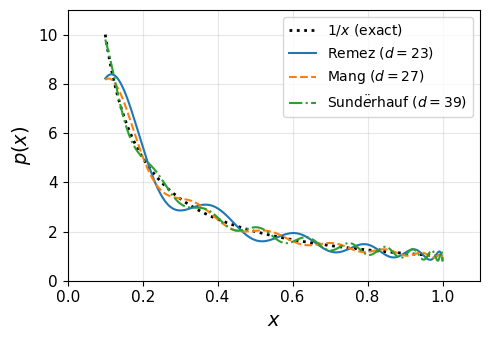

In [3]:
kappa   = 10
epsilon = 0.2
plot_base_polynomals(kappa=kappa, epsilon=epsilon)
plt.show()

## Plot errors

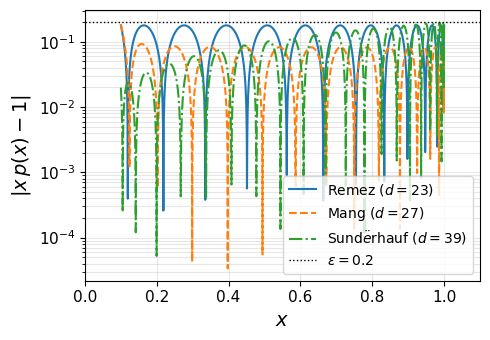

In [4]:
kappa   = 10
epsilon = 0.2
plot_base_polynomial_errors(kappa=kappa, epsilon=epsilon)
plt.show()

## Pure Spectral interpolation

Max tau for pure spectral polynomial: 16.1692


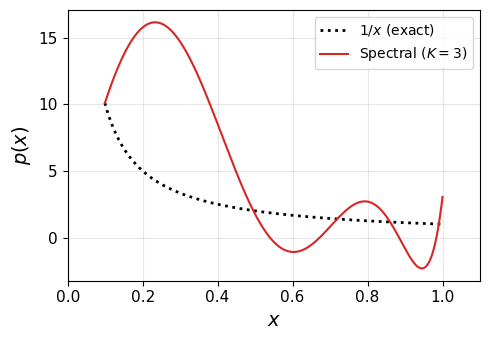

In [5]:
lam = np.array([0.1, 0.5, 1])
plot_pure_spectral_polynomial(lam)
plt.show()

## Spectrally bootstrapped polynomial and error

### Example 1: separated eigenvalues

Max tau on [a, 1]: base=8.3877, spectral=10.1258
Max error on [a, 1]: base=0.1785, spectral=0.3602


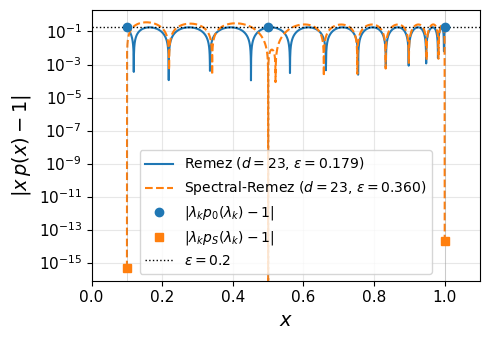

In [6]:
kappa = 10
epsilon = 0.2
K = 3
lam = np.array([1/kappa, 0.5, 1])
basePolynomial  = 'remez' # 'remez' or 'mang' or 'sunderhauf'
plot_bootstrapped_spectral_compare_error(kappa=kappa, epsilon=epsilon,
                                eigenvalues=lam , base=basePolynomial)
plt.show()

## Example 2: nearby eigenvalues

Max tau on [a, 1]: base=8.3877, spectral=10.0000
Max error on [a, 1]: base=0.1785, spectral=1.0036


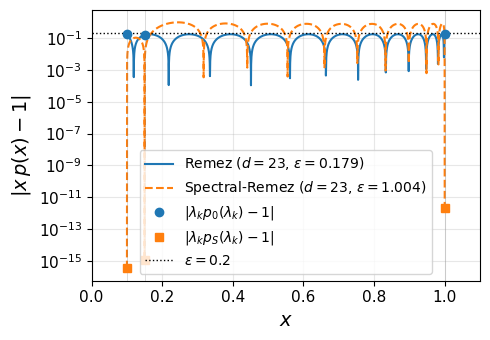

In [7]:
kappa = 10
epsilon = 0.2
K = 3
lam = np.array([1/kappa, 0.15, 1])
basePolynomial  = 'remez' # 'remez' or 'mang' or 'sunderhauf'
plot_bootstrapped_spectral_compare_error(kappa=kappa, epsilon=epsilon,
                                eigenvalues=lam , base=basePolynomial)
plt.show()

### Example 3: identical eigenvalues

Removing duplicate eigenvalues: 3 -> 2
Max tau on [a, 1]: base=9.8012, spectral=10.0000
Max error on [a, 1]: base=0.1988, spectral=0.1980


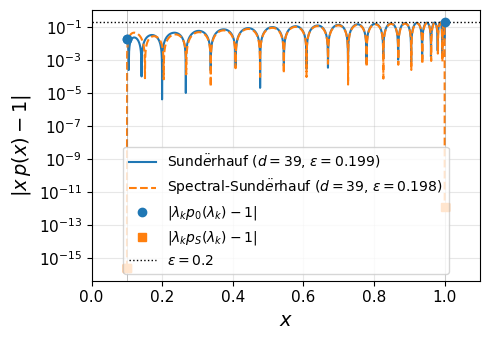

In [8]:
kappa = 10
epsilon = 0.2
K = 3
lam = np.array([1/kappa, 1/kappa, 1])
basePolynomial  = 'sunderhauf' # 'remez' or 'mang' or 'sunderhauf'
plot_bootstrapped_spectral_compare_error(kappa=kappa, epsilon=epsilon,
                                eigenvalues=lam , base=basePolynomial)
plt.show()

## Spectral Bootstrapping for a 1D FD Poisson

Max tau on [a, 1]: base=9.3732, spectral=9.4721
Max error on [a, 1]: base=0.0989, spectral=0.0978


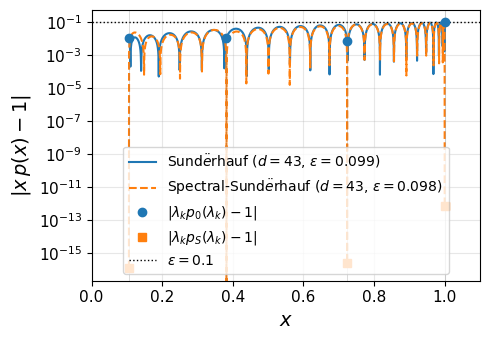

In [9]:
kappa   = 9.4721
epsilon = 0.1
lam = np.array([1/kappa, 0.381966, 0.723607, 1.000000])
basePolynomial  = 'sunderhauf' # 'remez' or 'mang' or 'sunderhauf'
plot_bootstrapped_spectral_compare_error(kappa=kappa, epsilon=epsilon,
                                eigenvalues=lam , base=basePolynomial)
plt.show()

## Accuracy Study

In [10]:
basePolynomial  = 'Mang' # 'Remez' or 'Mang' or 'Sunderhauf'
m = 2
KFactor = 0.5

print_accuracy_table_1D(m=m,KFactor = KFactor,base = basePolynomial)

N=4, kappa=9.47, K=2

Method                        eps      d   E_eig (K corrected)   E_eig (all N)
------------------------------------------------------------------------------
Mang                        0.200     25              1.92e-01        1.92e-01
Spectral-Mang (K=2)      0.200     25              2.22e-16        1.58e-01

Mang                        0.100     33              9.27e-02        9.27e-02
Spectral-Mang (K=2)      0.100     33              1.11e-16        1.51e-02

Mang                        0.010     57              9.05e-03        9.05e-03
Spectral-Mang (K=2)      0.010     57              1.00e-16        2.71e-03



## 1D Poisson Bootstrapped Spectral QSVT Expt

In [ ]:
results_uniform, x_cl_uniform = run_1d_Poisson_spectral_experiment(
        m=4,
        eps_loose=0.5,
        eps_tight=0.001,
        K_fraction=1.0,
        base='Remez',
        function_type="delta"
    )


1D Poisson QSVT spectral Experiment
m=4, N=16, K=16 (=100% of N)
eps_loose=0.5, eps_tight=0.001
base=Remez, function_type=delta
kappa=117.626, lam_min=0.990099, lam_max=0.008502
K smallest eigenvalues: [0.00850154 0.03371663 0.07478663 0.13031292 0.19840463 0.27674299
 0.36266027 0.45323066 0.54536989 0.63594028 0.72185756 0.80019591
 0.86828763 0.92381392 0.96488391 0.99009901]
C_true = 16.964918

--- Remez (eps=0.5) ---
Generated 248 phase angles for degree 247
Circuit width: 10, depth: 497
Running statevector simulation...

--- Remez (eps=0.001) ---


## 1D Poisson Perturbation Study

In [ ]:
results_uniform, x_cl_uniform = run_1d_Poisson_perturbation_experiment(m,
                                eps = 0.5,
                                K_fraction = 1.0,
                                eta_values = None,
                                n_trials = 10,
                                base = 'Sunderhauf',
                                function_type = "uniform")

## 2D Poisson QSVT

In [ ]:
m = 4
eps = 0.2
KRange  = [1,2,4,8,16, 32]
basePolynomial ='Mang' # 'Remez' or 'Mang' or 'Sunderhauf'
function_type = "uniform" # "uniform", "sine", "delta", or "random"
plot = True

run_2d_Poisson_QSVT_experiment(m, eps, KRange, basePolynomial, 
                               function_type=function_type, plotSolutions=plot)

## Find largest epsilon tp achieve high fidelty for a given m

In [ ]:
# ── Run sweep ────────────────────────────────────────────────────────────────
eps_candidates = [0.95, 0.9, 0.85, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2]
all_results = []
base = 'Mang'  # 'Remez' or 'Mang' or 'Sunderhauf'
mValues = [2, 3, 4, 5]
for m in mValues:
    print(f"\n{'='*60}")
    print(f"m = {m}")
    print(f"{'='*60}")
    results = find_max_epsilon(m, eps_candidates,base = base, fidelity_threshold=0.999999)
    all_results.extend(results)

# Add this after the sweep
for m_val in mValues:
    A, b = build_1d_poisson(m_val, function_type="uniform")
    lam = eigs_1d_poisson(m_val)
    A /= (1.01 * np.max(lam))
    lam /= (1.01 * np.max(lam))
    kappa = 1.0 / np.min(lam)
    p_tight = MangPolynomial(1.0/kappa, target_error=1e-3)
    d_tight = p_tight.mindegree()
    print(f"m={m_val}, kappa={kappa:.1f}, d_tight(eps=1e-3)={d_tight}")

# ── Summary table ────────────────────────────────────────────────────────────
print(f"\n{'='*80}")
print(f"Summary for {base}: largest eps with unit fidelity (F >= 0.999999)")
print(f"{'='*80}")
print(f"{'m':>3} {'N':>4} {'kappa':>8} {'eps_max':>8} {'d':>5} "
      f"{'sqrt(k)*log(1/e)':>18} {'Fidelity':>12}")
print("-" * 80)

for m in mValues:
    m_results = [r for r in all_results
                 if r['m'] == m and r['fidelity'] >= 0.999999]
    if m_results:
        best = max(m_results, key=lambda r: r['eps'])
        print(f"{best['m']:>3} {best['N']:>4} {best['kappa']:>8.1f} "
              f"{best['eps']:>8.2f} {best['d']:>5} "
              f"{best['sqrt_kap_log_inv_eps']:>18.2f} "
              f"{best['fidelity']:>12.8f}")


m = 2
degree override:  None
computed degree:  3
Generated 4 phase angles for degree 3
Circuit width: 6, depth: 9
Running statevector simulation...
  eps=0.95, d=3, n0=2, K=N=4, n0>=K: False
  eps=0.95, d=3, fidelity=0.54824625, tau=1.8, sqrt(kap)*log(1/eps)=0.16
degree override:  None
computed degree:  5
Generated 6 phase angles for degree 5
Circuit width: 6, depth: 13
Running statevector simulation...
  eps=0.90, d=5, n0=3, K=N=4, n0>=K: False
  eps=0.90, d=5, fidelity=0.94188519, tau=2.9, sqrt(kap)*log(1/eps)=0.32
degree override:  None
computed degree:  7
Generated 8 phase angles for degree 7
Circuit width: 6, depth: 17
Running statevector simulation...
  eps=0.85, d=7, n0=4, K=N=4, n0>=K: True
  eps=0.85, d=7, fidelity=1.00000000, tau=38.9, sqrt(kap)*log(1/eps)=0.50
degree override:  None
computed degree:  7
Generated 8 phase angles for degree 7
Circuit width: 6, depth: 17
Running statevector simulation...
  eps=0.80, d=7, n0=4, K=N=4, n0>=K: True
  eps=0.80, d=7, fidelity=1.0000

TypeError: MangPolynomial() takes no arguments